In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv(r'/content/drive/MyDrive/Advanced AI/moviereviews.tsv',sep='\t')
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [5]:
len(df)

2000

In [6]:
df.isnull().sum()


,0
label,0
review,35


In [8]:
df['label'].unique()
df['review'].describe()
df['label'].unique()
df['review'].describe()

,review
count,1965
unique,1939
top,
freq,27


In [9]:
import matplotlib.pyplot as plt

/tmp/ipython-input-851/46439651.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['review'].fillna('', inplace=True)


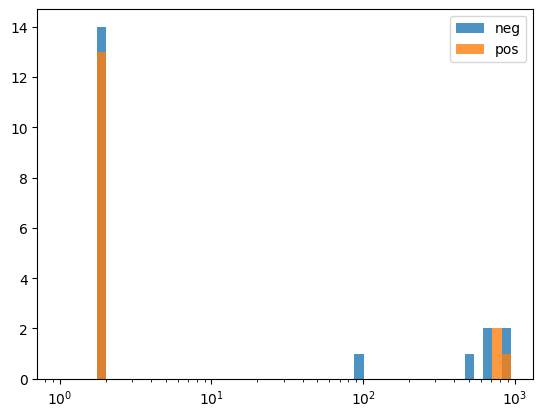

In [17]:
df['review'].fillna('', inplace=True)
df['length'] = df['review'].apply(len)

%matplotlib inline
plt.xscale('log')
bins=1.15**(np.arange(0,50))
plt.hist(df[df['label']=='neg']['length'],bins=bins,alpha=0.8)
plt.hist(df[df['label']=='pos']['length'],bins=bins,alpha=0.8)
plt.legend(('neg','pos'))
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# Define X and y
x = df['review']
y = df['label']

# Vectorize the text data
vectorizer = CountVectorizer()
x = vectorizer.fit_transform(x)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
print('training Data shape: ',x_train.shape)
print('testing Data shape: ',x_test.shape)
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(solver='lbfgs')
lr_model.fit(x_train,y_train)

training Data shape:  (1340, 38901)
testing Data shape:  (660, 38901)


LogisticRegression()

In [19]:
from sklearn import metrics
predictions=lr_model.predict(x_test)
print(metrics.confusion_matrix(y_test,predictions))
df=pd.DataFrame(metrics.confusion_matrix(y_test,predictions),index=['neg','pos'],columns=['neg','pos'])

[[286  48]
 [ 81 245]]


In [20]:
df

,neg,pos
neg,286,48
pos,81,245


In [21]:
from sklearn.naive_bayes import MultinomialNB
nb_model=MultinomialNB()
nb_model.fit(x_train,y_train)

MultinomialNB()

In [22]:
from sklearn import metrics
predictions=nb_model.predict(x_test)
print(metrics.confusion_matrix(y_test,predictions))

[[261  73]
 [ 59 267]]


In [24]:
df=pd.DataFrame(metrics.confusion_matrix(y_test,predictions),index=['neg','pos'],columns=['neg','pos'])
df

,neg,pos
neg,261,73
pos,59,267


In [25]:
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

         neg       0.82      0.78      0.80       334
         pos       0.79      0.82      0.80       326

    accuracy                           0.80       660
   macro avg       0.80      0.80      0.80       660
weighted avg       0.80      0.80      0.80       660



In [26]:
print(metrics.accuracy_score(y_test,predictions))

0.8


In [27]:
from sklearn.svm import SVC
svc_model = SVC(gamma ='auto')
svc_model.fit(x_train,y_train)

SVC(gamma='auto')

In [28]:
predictions = svc_model.predict(x_test)
print(metrics.confusion_matrix(y_test,predictions))

[[278  56]
 [150 176]]


In [29]:
print(metrics.classification_report(y_test,predictions))

              precision    recall  f1-score   support

         neg       0.65      0.83      0.73       334
         pos       0.76      0.54      0.63       326

    accuracy                           0.69       660
   macro avg       0.70      0.69      0.68       660
weighted avg       0.70      0.69      0.68       660

